In [ ]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
%pip install -q kornia segmentation-models-pytorch timm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ==========================================
#   Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                      hyper-parameters
#   runtime.log                     epoch logs + timing
#   chart_*_config.json             -chart render config
#   srunet_training_curves.png      loss/RMSE charts
#   srunet_eval_<date>.png          spatial eval chart
#   metrics.csv                     final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved â†’ {path}')
    return path


Run folder (placeholder): runs/20260402_041755_lead1d
[2026-04-02 04:17:55] === Run started  (id=20260402_041755) ===
[2026-04-02 04:17:55] Run dir: runs/20260402_041755_lead1d


## Import Library

In [4]:
import numpy as np
import xarray as xr
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import kornia

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
## Config
# Perfect Prognosis: X = low-res ERA5, Y = high-res ERA5
# No NWP model lead time  set lead_days = 0 to mark PP scenario
lead_days = 0
scale = 6
seed = 42
BATCH_SIZE = 32

# Pretrained UNet settings (SMP)
ENCODER_NAME = "resnet34"
ENCODER_WEIGHTS = "imagenet"  # pretrained encoder
CHECKPOINT_PATH = ""  # optional .pt/.pth to continue fine-tuning
FREEZE_ENCODER = False
RUN_TRAINING = True
TRAIN_EPOCHS = 100
TRAIN_LR = 5e-4
TRAIN_PATIENCE = 7

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

#  Refresh RUN_DIR now that lead_days is defined 
RUN_DIR = os.path.join('runs', f'{_run_id}')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

#  Persist config 
_config = {
    'scenario'         : 'scenario2-unet-mae-pretrained-smp',
    'lead_days'        : lead_days,
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'ENCODER_NAME'     : ENCODER_NAME,
    'ENCODER_WEIGHTS'  : ENCODER_WEIGHTS,
    'CHECKPOINT_PATH'  : CHECKPOINT_PATH,
    'FREEZE_ENCODER'   : FREEZE_ENCODER,
    'RUN_TRAINING'     : RUN_TRAINING,
    'TRAIN_EPOCHS'     : TRAIN_EPOCHS,
    'TRAIN_LR'         : TRAIN_LR,
    'TRAIN_PATIENCE'   : TRAIN_PATIENCE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved â†’ {_cfg_path}')

Run folder: runs/20260402_041755
[2026-04-02 04:17:57] Config saved â†’ runs/20260402_041755/config.json


In [6]:
# Reproducibility
np.random.seed(seed)
torch.manual_seed(seed)

## Load Datasets

In [7]:
ds_hr = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [ ]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint  build LR from HR truth
# =========================================
scale = 6

ds_hr = ds_hr.sortby("latitude")  # ensure south â†’ north

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

#  Force start like forecast-correction notebook 
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

#  Snap to truth grid indices 
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

#  Available truth points from start 
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

#  Max LR points truth can support 
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

#  Clamp to U-Net friendly size (24Ã—32) 
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

#  Slice truth by exact count (HR target) 
ds_tr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

#  Build LR grid from HR stride 
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

#  Regrid HR -> LR with xESMF 
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
    ignore_degenerate=True,
)
ds_lr = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_lr.longitude)
LOW_LAT = len(ds_lr.latitude)

print(f"\nLow Resolution domain : lon {ds_lr.longitude.values[0]:.2f}â†’{ds_lr.longitude.values[-1]:.2f}"
      f"  lat {ds_lr.latitude.values[0]:.2f}â†’{ds_lr.latitude.values[-1]:.2f}")
print(f"high resolution domain    : lon {ds_tr.longitude.values[0]:.2f}â†’{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}â†’{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal low resolution grid : {LOW_LAT} lat Ã— {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat Ã— {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_lr.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_lr.latitude.values,  atol=1e-8)
assert lon_ok and lat_ok, "LR grid does not align with HR stride  check scale factor!"
print(f"Grid alignment check passed (lon_ok={lon_ok}, lat_ok={lat_ok})")

#  Perfect Prognosis aliases 
# Scenario 2 is Perfect Prognosis: the "forecast" input (X) is ERA5 itself
# degraded to low resolution.  There is no separate NWP model output.
#   ds_fc         â†’ low-res ERA5  (predictor / pseudo-forecast, 24Ã—32)
#   ds_tr_aligned â†’ high-res ERA5 truth, cropped to the same domain (144Ã—192)
ds_fc         = ds_lr   # alias  used throughout downstream cells
ds_tr_aligned = ds_tr   # alias  out downstream cells
print("Perfect Prognosis aliases set:")
print(f"  ds_fc         = ds_lr  ({LOW_LAT}Ã—{LOW_LON})")
print(f"  ds_tr_aligned = ds_tr  ({HIGH_LAT}Ã—{HIGH_LON})")


lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Low Resolution domain : lon 90.00â†’136.50  lat -13.50â†’21.00
high resolution domain    : lon 90.00â†’137.75  lat -13.50â†’22.25

Final low resolution grid : 24 lat Ã— 32 lon
Final truth grid    : 144 lat Ã— 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Grid alignment check passed (lon_ok=True, lat_ok=True)
Perfect Prognosis aliases set:
  ds_fc         = ds_lr  (24Ã—32)
  ds_tr_aligned = ds_tr  (144Ã—192)


## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_lr, "Low-res")
check_nan_summary(ds_hr, "Truth (High-res)")


==== Low-res ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Data model preparation

In [ ]:
# ==========================================
# Variable stacking
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_lr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Fill NaNs in forecast (X) before any processing
# X has ~0.027 % NaN values (confirmed in missing-value check above).
# Strategy: per-channel spatial mean imputation — fast and unbiased.
for _c in range(X.shape[1]):
    _ch   = X[:, _c, :, :]                          # (N, H, W)
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)                     # scalar fallback
        _ch[_mask] = _fill
        X[:, _c, :, :] = _ch
        print(f"  X channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(X).any(), "X still contains NaNs after imputation!"

#  Fill NaNs in truth (Y) 
for _c in range(Y.shape[1]):
    _ch   = Y[:, _c, :, :]
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)
        _ch[_mask] = _fill
        Y[:, _c, :, :] = _ch
        print(f"  Y channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(Y).any(), "Y still contains NaNs after imputation!"
print("X NaN fill complete no NaNs remain.")

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2 Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

# ==========================================
# 2.5 Log-transform precipitation BEFORE normalisation
# ==========================================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"Before log1p Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

print(f"After  log1p X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"After  log1p Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

# ==========================================
# 3 Train / Val / Test split (date-based)
#    Split BEFORE normalization!
#    Keep temporal order no shuffle
# ==========================================
times = ds_lr.time.values  # Perfect Prognosis: use ds_lr (= ds_fc alias)
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask   = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask  = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

assert train_mask.any(), "No samples found for train date range"
assert val_mask.any(), "No samples found for val date range"
assert test_mask.any(), "No samples found for test date range"

X_train = X[train_mask]
X_val   = X[val_mask]
X_test  = X[test_mask]

Y_train = Y[train_mask]
Y_val   = Y[val_mask]
Y_test  = Y[test_mask]

print("\nDate-based split sizes:")
print(f"  Train : {len(X_train)} ({str(times[train_mask][0])[:10]} â†’ {str(times[train_mask][-1])[:10]})")
print(f"  Val   : {len(X_val)} ({str(times[val_mask][0])[:10]} â†’ {str(times[val_mask][-1])[:10]})")
print(f"  Test  : {len(X_test)} ({str(times[test_mask][0])[:10]} â†’ {str(times[test_mask][-1])[:10]})")

# ==========================================
# 4 Normalization train stats only!
#    SEPARATE stats for X (low-res) and Y (high-res)
#    because they live on different grids
# ==========================================
# X stats: (1, C, 1, 1)
X_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
X_std  = X_train.std( axis=(0, 2, 3), keepdims=True)

# Y stats: (1, C, 1, 1)
Y_mean = Y_train.mean(axis=(0, 2, 3), keepdims=True)
Y_std  = Y_train.std( axis=(0, 2, 3), keepdims=True)

X_train = (X_train - X_mean) / (X_std + 1e-6)
X_val   = (X_val   - X_mean) / (X_std + 1e-6)
X_test  = (X_test  - X_mean) / (X_std + 1e-6)

Y_train = (Y_train - Y_mean) / (Y_std + 1e-6)
Y_val   = (Y_val   - Y_mean) / (Y_std + 1e-6)
Y_test  = (Y_test  - Y_mean) / (Y_std + 1e-6)

# Save stats for denormalization at inference
# NOTE: expm1() needed after denormalising the TP channel
norm_stats = {
    "X_mean": torch.tensor(X_mean, dtype=torch.float32),
    "X_std" : torch.tensor(X_std,  dtype=torch.float32),
    "Y_mean": torch.tensor(Y_mean, dtype=torch.float32),
    "Y_std" : torch.tensor(Y_std,  dtype=torch.float32),
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,
}
print("\nX norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={X_mean[0,i,0,0]:.4f}, std={X_std[0,i,0,0]:.4f}")
print("Y norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={Y_mean[0,i,0,0]:.4f}, std={Y_std[0,i,0,0]:.4f}")

# ==========================================
# 5 Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6 DataLoaders
# ==========================================

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7 Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    """Reverse z-score, then expm1 on the TP channel."""
    mu  = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])  # reverse log1p
    return out

X NaN fill complete â€” no NaNs remain.
Before axis check:
X shape: (7304, 4, 24, 32)
Y shape: (7304, 4, 144, 192)
Corrected shapes:
X: (7304, 4, 24, 32)
Y: (7304, 4, 144, 192)

Before log1p â€” X TP min/max: -0.0000 / 0.4984
Before log1p â€” Y TP min/max: -0.0000 / 0.6023
After  log1p â€” X TP min/max: 0.0000 / 0.4044
After  log1p â€” Y TP min/max: 0.0000 / 0.4715

Date-based split sizes:
  Train : 5841 (2018-01-01 â†’ 2021-12-31)
  Val   : 721 (2022-01-01 â†’ 2022-06-30)
  Test  : 733 (2022-07-01 â†’ 2022-12-31)

X norm stats per channel:
  10m_u_component_of_wind: mean=-1.1941, std=4.1289
  10m_v_component_of_wind: mean=0.3375, std=3.4082
  2m_temperature: mean=300.0585, std=2.2168
  total_precipitation_24hr: mean=0.0060, std=0.0104
Y norm stats per channel:
  10m_u_component_of_wind: mean=-1.1902, std=4.0955
  10m_v_component_of_wind: mean=0.2801, std=3.3993
  2m_temperature: mean=300.0140, std=2.3289
  total_precipitation_24hr: mean=0.0061, std=0.0105

Final tensor shapes:
  X_tra

In [11]:
# ==========================================
# Pretrained UNet (segmentation_models_pytorch)
# ==========================================

class PretrainedUNetSR(nn.Module):
    """
    Upsample LR input (24x32) -> HR grid (144x192), then predict with pretrained UNet.
    Output shape matches HR target shape.
    """
    def __init__(self, in_ch=4, out_ch=4, encoder_name="resnet34", encoder_weights="imagenet"):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_ch,
            classes=out_ch,
            activation=None,
        )

    def forward(self, x, out_hw=None):
        if out_hw is None:
            out_hw = (x.shape[-2] * 6, x.shape[-1] * 6)
        x_up = F.interpolate(x, size=out_hw, mode="bilinear", align_corners=False)
        return self.unet(x_up)


if __name__ == "__main__":
    model = PretrainedUNetSR(
        in_ch=4,
        out_ch=4,
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
    )
    dummy = torch.randn(2, 4, 24, 32)
    out = model(dummy, out_hw=(144, 192))
    print("Input  :", dummy.shape)
    print("Output :", out.shape)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {total_params:,}")

Input  : torch.Size([2, 4, 24, 32])
Output : torch.Size([2, 4, 144, 192])
Params : 24,439,940


In [ ]:
class CombinedLoss(nn.Module):
    """
    Combined loss using DSSIM from Kornia.

    Modes:
    - 'dssim'      : Pure DSSIM
    - 'mae'        : Pure MAE
    - 'dssim+mse'  : alpha * DSSIM + beta * MSE
    - 'dssim+mae'  : alpha * DSSIM + beta * MAE
    """
    def __init__(self, alpha=0.8, beta=0.2, mode='dssim'):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mode  = mode
        self.dssim = kornia.losses.SSIMLoss(window_size=11, reduction='mean')

    def _zero(self, ref: torch.Tensor) -> torch.Tensor:
        """Device-safe zero scalar."""
        return torch.tensor(0.0, device=ref.device, dtype=ref.dtype)

    def _gradient_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """L1 loss on spatial gradients (sharpens edges)."""
        def grad(x):
            dy = x[:, :, 1:, :] - x[:, :, :-1, :]
            dx = x[:, :, :, 1:] - x[:, :, :, :-1]
            return dy, dx
        pred_dy,   pred_dx   = grad(pred)
        target_dy, target_dx = grad(target)
        return F.l1_loss(pred_dy, target_dy) + F.l1_loss(pred_dx, target_dx)

    def forward(self, pred: torch.Tensor, target: torch.Tensor):
        """
        Returns:
            total_loss  : scalar used for .backward()
            loss_a      : first component (detached), for logging
            loss_b      : second component (detached), for logging
        """
        if self.mode == 'dssim':
            d = self.dssim(pred, target)
            return d, d.detach(), self._zero(pred)

        elif self.mode == 'mae':
            mae = F.l1_loss(pred, target)
            return mae, mae.detach(), self._zero(pred)

        elif self.mode == 'dssim+mse':
            d   = self.dssim(pred, target)
            mse = F.mse_loss(pred, target)
            total = self.alpha * d + self.beta * mse
            return total, d.detach(), mse.detach()

        elif self.mode == 'dssim+mae':
            d   = self.dssim(pred, target)
            mae = F.l1_loss(pred, target)
            total = self.alpha * d + self.beta * mae
            return total, d.detach(), mae.detach()

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

## Pretrained UNet Scenario (SMP)
This notebook uses `segmentation_models_pytorch.Unet` with a pretrained encoder (`imagenet`) and upsamples LR inputs to HR size before prediction.

In [13]:
def build_model_for_run(in_ch=4, out_ch=4):
    model = PretrainedUNetSR(
        in_ch=in_ch,
        out_ch=out_ch,
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
    )

    if CHECKPOINT_PATH:
        if not os.path.exists(CHECKPOINT_PATH):
            raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
        ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
        state_dict = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        _log(f"Loaded checkpoint: {CHECKPOINT_PATH}")
        print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
        print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")

    if FREEZE_ENCODER:
        frozen_params = 0
        for p in model.unet.encoder.parameters():
            p.requires_grad = False
            frozen_params += p.numel()
        _log(f"Frozen encoder params: {frozen_params}")
        print(f"Frozen encoder params: {frozen_params}")

    return model

In [ ]:
def train(
    model,
    train_loader,
    val_loader,
    norm_stats,
    epochs=50,
    lr=5e-4,
    patience=7,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    _log(f"Training started  epochs={epochs} lr={lr} patience={patience}")
    _train_t0 = _dt.datetime.now()
    model = model.to(device)

    criterion = CombinedLoss(mode='mae').to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse": [], "train_grad": [],
        "val_metrics": [],
    }
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_mses, train_grads = [], [], []

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch, out_hw=Y_batch.shape[-2:])
            loss, mse, grad = criterion(pred, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_mses.append(mse.item())
            train_grads.append(grad.item())

        scheduler.step()

        model.eval()
        val_losses   = []
        all_preds    = []
        all_targets  = []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred = model(X_batch, out_hw=Y_batch.shape[-2:])
                loss, _, _ = criterion(pred, Y_batch)
                val_losses.append(loss.item())
                all_preds.append(pred.cpu())
                all_targets.append(Y_batch.cpu())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        # Metrics on full val set
        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mse"].append(np.mean(train_mses))
        history["train_grad"].append(np.mean(train_grads))

        _emsg = (f"Epoch [{epoch:03d}/{epochs}] train={train_loss:.4f} "
                 f"val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")
        print(_emsg)
        _log(_emsg)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "val_loss": val_loss,
                "X_mean": norm_stats["X_mean"].clone(),
                "X_std": norm_stats["X_std"].clone(),
                "Y_mean": norm_stats["Y_mean"].clone(),
                "Y_std": norm_stats["Y_std"].clone(),
                "variables": VARS,
                "tp_index": TP_IDX,
                "log1p_applied": True,
                "encoder_name": ENCODER_NAME,
                "encoder_weights": ENCODER_WEIGHTS,
            }, os.path.join(RUN_DIR, "best_model.pt"))
            print(f"  Saved best model (val={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}  no improvement for {patience} epochs.")
                best_ckpt = torch.load(os.path.join(RUN_DIR, "best_model.pt"), map_location=device, weights_only=False)
                model.load_state_dict(best_ckpt["model_state"])
                print(f"  Restored best weights from epoch {best_ckpt['epoch']} (val={best_ckpt['val_loss']:.4f})")
                break

    _elapsed = _dt.datetime.now() - _train_t0
    _log(f"Training finished  elapsed={str(_elapsed).split(chr(46))[0]}  best_val_loss={best_val_loss:.6f}")
    return history

In [15]:
model = build_model_for_run(in_ch=4, out_ch=4)

if RUN_TRAINING:
    history = train(
        model, train_loader, val_loader, norm_stats,
        epochs=TRAIN_EPOCHS, lr=TRAIN_LR, patience=TRAIN_PATIENCE,
    )
else:
    history = {"train_loss": [float("nan")], "val_loss": [float("nan")]}
    _log("RUN_TRAINING=False -> training skipped")
    print("Training skipped. Set RUN_TRAINING=True to fine-tune.")

[2026-04-02 04:18:58] Training started  epochs=100 lr=0.0005 patience=7
Epoch [001/100] train=0.2999 val=0.2061  lr=5.00e-04
[2026-04-02 04:19:22] Epoch [001/100] train=0.2999 val=0.2061  lr=5.00e-04
  Saved best model (val=0.2061)
Epoch [002/100] train=0.2075 val=0.1938  lr=5.00e-04
[2026-04-02 04:19:45] Epoch [002/100] train=0.2075 val=0.1938  lr=5.00e-04
  Saved best model (val=0.1938)
Epoch [003/100] train=0.1921 val=0.1774  lr=4.99e-04
[2026-04-02 04:20:03] Epoch [003/100] train=0.1921 val=0.1774  lr=4.99e-04
  Saved best model (val=0.1774)
Epoch [004/100] train=0.1841 val=0.1698  lr=4.98e-04
[2026-04-02 04:20:14] Epoch [004/100] train=0.1841 val=0.1698  lr=4.98e-04
  Saved best model (val=0.1698)
Epoch [005/100] train=0.1779 val=0.1628  lr=4.97e-04
[2026-04-02 04:20:25] Epoch [005/100] train=0.1779 val=0.1628  lr=4.97e-04
  Saved best model (val=0.1628)
Epoch [006/100] train=0.1720 val=0.1622  lr=4.96e-04
[2026-04-02 04:20:36] Epoch [006/100] train=0.1720 val=0.1622  lr=4.96e-04


[2026-04-02 04:27:45] Chart config saved â†’ chart_training_curves_config.json
[2026-04-02 04:27:45] Chart saved â†’ runs/20260402_041755/srunet_training_curves.png


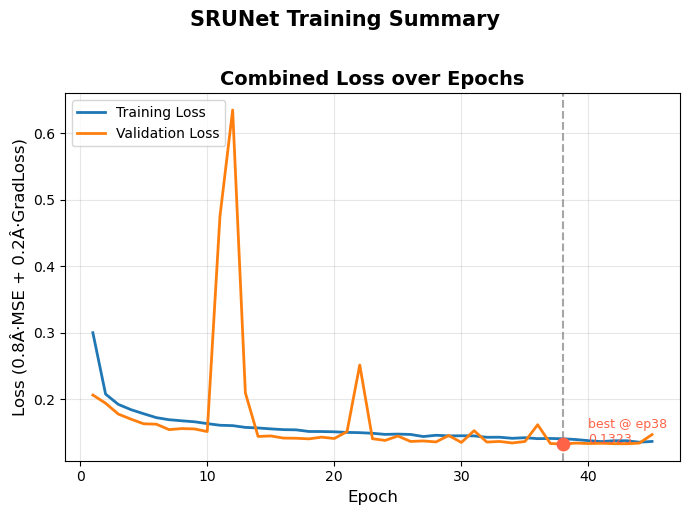


Final Training Loss: 0.136230
Final Validation Loss: 0.146598


In [16]:
#  Save chart config 
_chart1_cfg = {
    'chart'         : 'training_curves',
    'figsize'       : [14, 5],
    'loss_alpha'    : 0.8,
    'loss_beta'     : 0.2,
    'best_epoch'    : int(np.argmin(history['val_loss']) + 1),
    'best_val_loss' : float(min(history['val_loss'])),
}
_json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
_log('Chart config saved â†’ chart_training_curves_config.json')

import matplotlib.pyplot as plt

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

#  Left: Loss (combined = 0.8*MSE + 0.2*GradLoss) 
ax1.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Validation Loss", linewidth=2)

best_epoch = np.argmin(history["val_loss"]) + 1
best_loss  = min(history["val_loss"])
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9, color="tomato",
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (0.8Â·MSE + 0.2Â·GradLoss)", fontsize=12)
ax1.set_title("Combined Loss over Epochs", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.suptitle("SRUNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "srunet_training_curves.png", dpi=150)
plt.show()

print(f"\nFinal Training Loss: {history['train_loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")

[2026-04-02 04:27:45] Chart config saved â†’ chart_spatial_eval_config.json


/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


[2026-04-02 04:27:57] Chart saved â†’ runs/20260402_041755/srunet_eval_2022-08-01.png


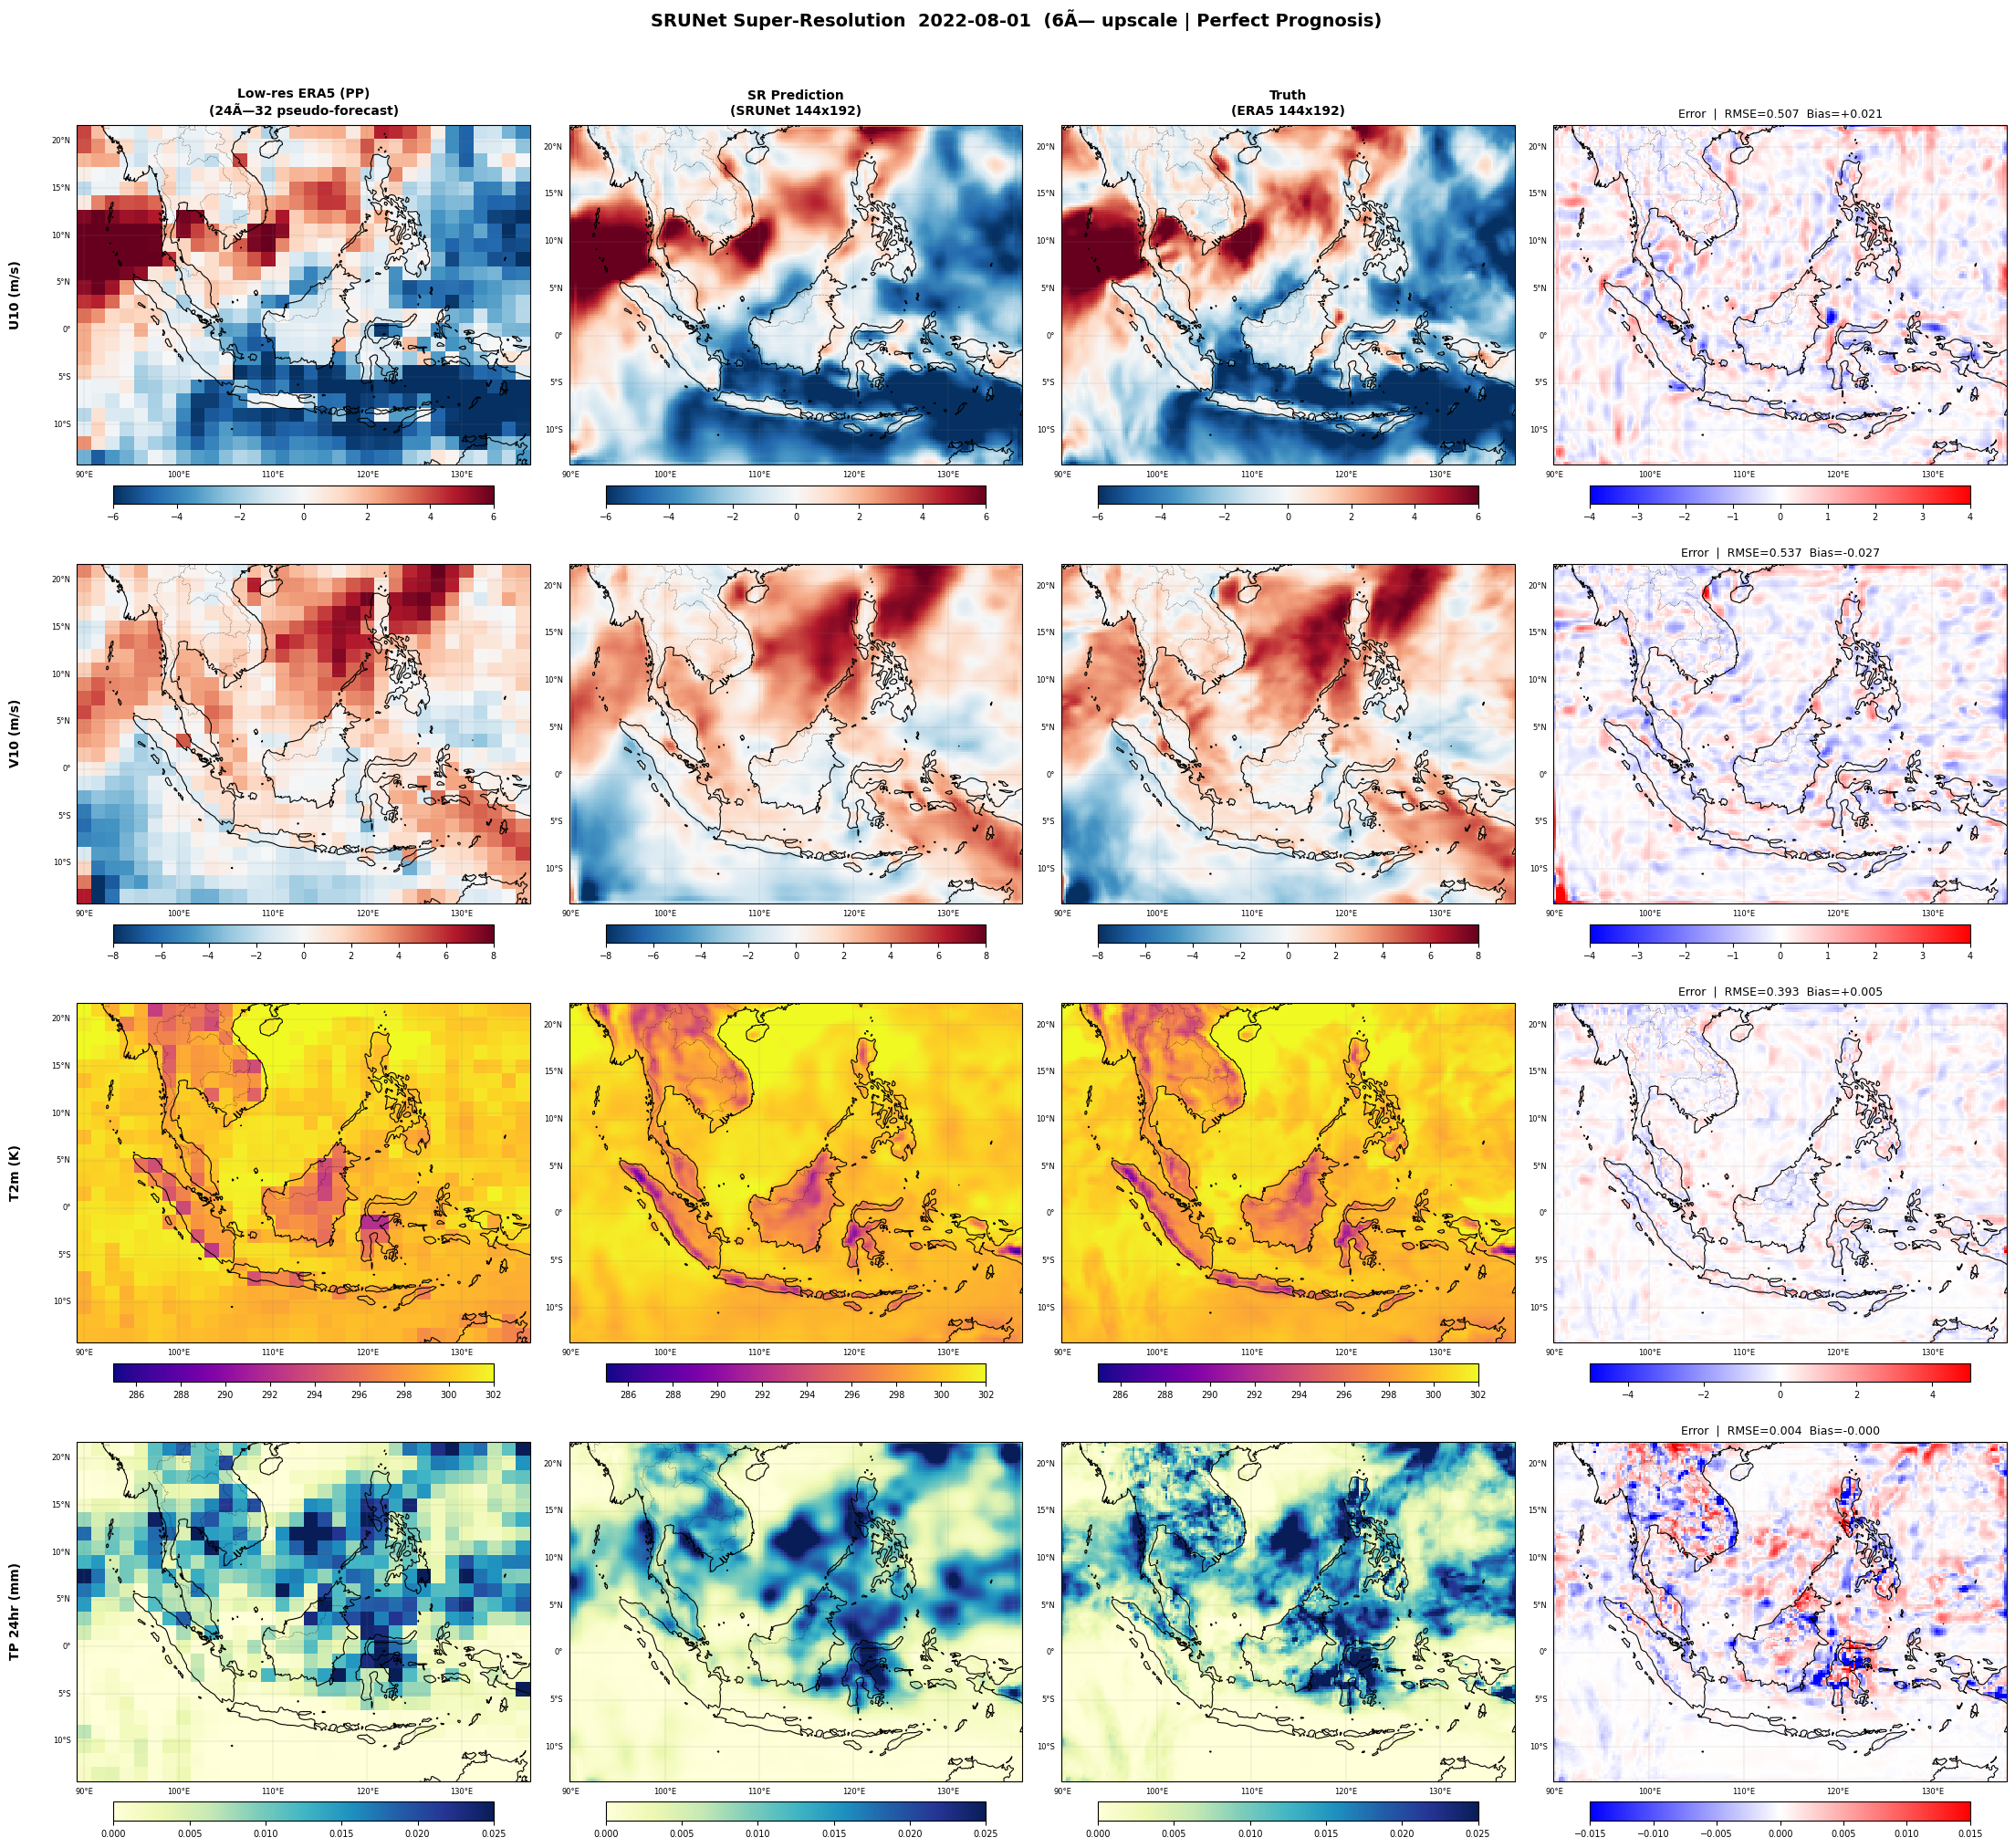

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np


# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps  same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

#  Save chart config 
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : 0,  # Perfect Prognosis  no NWP lead time
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved â†’ chart_spatial_eval_config.json')



# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date)).time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} â†’ {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(model.parameters()).device
model.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = model(X_sample).cpu()

# Denormalize  keep T2m in Kelvin (no Kâ†’Â°C) to match regrid notebook
Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 24,  32)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc.longitude.values   # (32,)
lats_lr = ds_fc.latitude.values    # (24,)
lons_hr = ds_tr_aligned.longitude.values  # (192,)
lats_hr = ds_tr_aligned.latitude.values   # (144,)

# ==============================
# Plot: 4 rows Ã— 4 cols  (matching regrid_correction.ipynb layout)
# cols: Raw FC | Prediction (SR) | Truth (ERA5) | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Low-res ERA5 (PP)\n(24Ã—32 pseudo-forecast)",
    "SR Prediction\n(SRUNet 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

# Colormaps  same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    # PyTorch (C, H, W) â†’ numpy (H, W)
    raw_v  = X_dn[v].numpy()       # (24,  32)
    pred_v = Y_pred[v].numpy()     # (144, 192)
    true_v = Y_true[v].numpy()     # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        # Ensure data shape is (n_lats, n_lons) for pcolormesh
        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"SRUNet Super-Resolution  {str(target_date)[:10]}  (6Ã— upscale | Perfect Prognosis)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
save_fig(fig, f"srunet_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

In [18]:
# ==========================================
# Helpers: compute_metrics / print_metrics
# ==========================================

def compute_metrics(preds_norm, targets_norm, Y_mu, Y_sig):
    p_dn = denormalize(preds_norm.clone(), Y_mu, Y_sig).numpy()
    t_dn = denormalize(targets_norm.clone(), Y_mu, Y_sig).numpy()

    results = {}
    for vi, label in enumerate(VAR_LABELS):
        p = p_dn[:, vi]
        t = t_dn[:, vi]
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        pd_ = p - p.mean()
        td_ = t - t.mean()
        with np.errstate(divide="ignore", invalid="ignore"):
            corr = float(
                np.sum(pd_ * td_) /
                (np.sqrt(np.sum(pd_**2) * np.sum(td_**2)) + 1e-12)
            )
        results[label] = {"RMSE": rmse, "MAE": mae, "Bias": bias, "Corr": corr}
    return results


def print_metrics(metrics: dict, prefix: str = "Metrics"):
    hdr = f"\n{prefix}"
    line = "-" * 72
    print(hdr)
    print(line)
    _log(hdr)
    for label, m in metrics.items():
        r, a, b, c = m["RMSE"], m["MAE"], m["Bias"], m["Corr"]
        msg = (f"  {label:<22}  RMSE={r:8.4f}  MAE={a:8.4f}  "
               f"Bias={b:+8.4f}  Corr={c:6.4f}")
        print(msg)
        _log(msg)
    print(line)


def evaluate_test(model, test_loader, norm_stats,
                  device="cuda" if torch.cuda.is_available() else "cpu"):
    ckpt_path = os.path.join(RUN_DIR, "best_model.pt")
    _log(f"Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()

    Y_mu = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch, out_hw=Y_batch.shape[-2:])
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix="ðŸ§ª Test Set Metrics")
    return metrics, all_preds, all_targets


test_metrics, test_preds, test_targets = evaluate_test(
    model, test_loader, norm_stats
)

[2026-04-02 04:27:59] Loading checkpoint: runs/20260402_041755/best_model.pt

ðŸ§ª Test Set Metrics
------------------------------------------------------------------------
[2026-04-02 04:28:01] 
ðŸ§ª Test Set Metrics
  U10 (m/s)               RMSE=  0.5952  MAE=  0.4092  Bias= +0.0274  Corr=0.9889
[2026-04-02 04:28:01]   U10 (m/s)               RMSE=  0.5952  MAE=  0.4092  Bias= +0.0274  Corr=0.9889
  V10 (m/s)               RMSE=  0.5954  MAE=  0.4154  Bias= -0.0654  Corr=0.9840
[2026-04-02 04:28:01]   V10 (m/s)               RMSE=  0.5954  MAE=  0.4154  Bias= -0.0654  Corr=0.9840
  T2m (K)                 RMSE=  0.4673  MAE=  0.3131  Bias= +0.0040  Corr=0.9764
[2026-04-02 04:28:01]   T2m (K)                 RMSE=  0.4673  MAE=  0.3131  Bias= +0.0040  Corr=0.9764
  TP 24hr (mm)            RMSE=  0.0051  MAE=  0.0022  Bias= -0.0002  Corr=0.9058
[2026-04-02 04:28:01]   TP 24hr (mm)            RMSE=  0.0051  MAE=  0.0022  Bias= -0.0002  Corr=0.9058
--------------------------------------

In [ ]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np
import xarray as xr

Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]

# Denormalize model predictions/targets (physical space)
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

# Compute baseline RMSE on full HR grid (time-aligned only, not lat/lon inner join)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    # Align only along time; keep each dataset's native spatial grids
    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    # Baseline: bilinear upsample LR -> HR truth grid
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

BASELINE_EPS = 1e-8

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.")

# Save final test metrics to CSV
import csv as _csv

_metrics_rows = []
for v_idx, v_name in enumerate(VARS):
    _pv = y_pred_phys[:, v_idx, :, :]
    _tv = y_true_phys[:, v_idx, :, :]
    _n = min(_pv.shape[0], _tv.shape[0])
    _pv = _pv[:_n]
    _tv = _tv[:_n]

    _rmse_g = np.sqrt(np.mean((_pv - _tv) ** 2, axis=0))
    _mae_g = np.mean(np.abs(_pv - _tv), axis=0)
    _bias_g = np.mean(_pv - _tv, axis=0)
    _pd = _pv - np.mean(_pv, axis=0)
    _td = _tv - np.mean(_tv, axis=0)
    _cov = np.sum(_pd * _td, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _corr_g = _cov / np.sqrt(np.sum(_pd**2, axis=0) * np.sum(_td**2, axis=0))

    _rmse = float(np.nanmean(_rmse_g))
    _rbase = baseline_rmse_by_var[v_name]
    _metrics_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[v_idx],
        'RMSE': _rmse,
        'MAE': float(np.nanmean(_mae_g)),
        'Bias': float(np.nanmean(_bias_g)),
        'Corr': float(np.nanmean(_corr_g)),
        'Baseline_RMSE': _rbase,
        'Skill': float(1.0 - (_rmse / _rbase)) if _rbase > BASELINE_EPS else 0.0,
    })

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved â†’ {_csv_path}')

# Log run completion
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\nâœ… All outputs saved to: {RUN_DIR}')


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   0.5537 |   0.4092 |  +0.0274 |   0.9567 |         0.6595 |  +0.1603
V10 (m/s)          |   0.5572 |   0.4154 |  -0.0654 |   0.9498 |         0.6327 |  +0.1194
T2m (K)            |   0.4072 |   0.3131 |  +0.0040 |   0.9435 |         0.5610 |  +0.2743
TP 24hr (mm)       |   0.0044 |   0.0022 |  -0.0002 |   0.9084 |         0.0046 |  +0.0398

Skill > 0 means SRUNet improves over bilinear interpolation baseline.
[2026-04-02 04:28:03] Metrics saved â†’ runs/20260402_041755/metrics.csv
[2026-04-02 04:28:03] === Run finished  total_elapsed=0:10:07 ===
[2026-04-02 04:28:03] All outputs in: runs/20260402_041755

âœ… All outputs saved to: runs/20260402_041755
